# Build UN agency panel

Reads `data/raw/pivot.csv` (CEB Financial Statistics revenue, long format) and produces `data/interim/un_panel.parquet`: one row per `(agency, year)` with total revenue and a breakdown by `rev_type`.

Filters to ECOSOC-mandate-relevant agencies; keeps a full panel as well for reference.

## 0. Setup

In [1]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd().parent
RAW = ROOT / "data" / "raw" / "pivot.csv"
INTERIM = ROOT / "data" / "interim"
INTERIM.mkdir(parents=True, exist_ok=True)

# ECOSOC-mandate-relevant subset (matches names as they appear in pivot.csv)
ECOSOC_AGENCIES = [
    "UNDP", "UNICEF", "UNFPA", "UNWOMEN", "WFP", "FAO", "WHO",
    "UNESCO", "ILO", "UNHABITAT", "UNEP", "UNHCR", "UNRWA",
    "UNAIDS", "UNCDF", "UNCCD", "UNFCCC", "UNIDO", "IFAD",
]
print("raw:", RAW)

raw: /Users/latahviawilliams/Downloads/Big_Data_export/final_project/ecosoc/data/raw/pivot.csv


## 1. Load and clean

`amount` in pivot.csv uses spaces as thousands separators (e.g. `119 158 506`). Strip them and cast to float.

In [2]:
df = pd.read_csv(RAW, dtype=str)
df.columns = [c.strip() for c in df.columns]
df["amount"] = (df["amount"].astype(str)
                .str.replace("\u00a0", "", regex=False)
                .str.replace(" ", "", regex=False)
                .str.replace(",", "", regex=False))
df["amount"] = pd.to_numeric(df["amount"], errors="coerce")
df["calendar_year"] = pd.to_numeric(df["calendar_year"], errors="coerce").astype("Int64")
df = df.dropna(subset=["amount", "calendar_year"])
df = df.rename(columns={"calendar_year": "year"})
df["year"] = df["year"].astype(int)
print("rows:", len(df), "agencies:", df.agency.nunique(), "years:", df.year.min(), "-", df.year.max())
df.head()

rows: 2779 agencies: 48 years: 2011 - 2024


,agency,sub_agency,rev_type,sub_type,year,amount
0,CTBTO,CTBTO,Assessed contributions,R01,2017,119158506.0
1,CTBTO,CTBTO,Assessed contributions,R01,2018,128036236.5
2,CTBTO,CTBTO,Assessed contributions,R01,2019,127055587.0
3,CTBTO,CTBTO,Assessed contributions,R01,2020,131283366.0
4,CTBTO,CTBTO,Assessed contributions,R01,2021,135517220.0


## 2. Aggregate to (agency, year)

In [3]:
panel = (df.groupby(["agency", "year"], as_index=False)
           .agg(revenue_usd=("amount", "sum"),
                n_subagencies=("sub_agency", "nunique")))

# rev_type breakdown (assessed vs. voluntary, etc.) wide-form
by_type = (df.groupby(["agency", "year", "rev_type"], as_index=False)
             .amount.sum()
             .pivot(index=["agency", "year"], columns="rev_type", values="amount")
             .fillna(0)
             .reset_index())
by_type.columns = [c if c in {"agency", "year"}
                   else "rev_" + str(c).lower().replace(" ", "_").replace("-", "_")
                   for c in by_type.columns]

panel = panel.merge(by_type, on=["agency", "year"], how="left")
panel["is_ecosoc_relevant"] = panel.agency.isin(ECOSOC_AGENCIES)

out_full = INTERIM / "un_panel_full.parquet"
panel.to_parquet(out_full, index=False)
print(f"wrote {out_full} ({len(panel)} rows, {panel.agency.nunique()} agencies)")

panel_e = panel[panel.is_ecosoc_relevant].drop(columns=["is_ecosoc_relevant"]).reset_index(drop=True)
out_e = INTERIM / "un_panel.parquet"
panel_e.to_parquet(out_e, index=False)
print(f"wrote {out_e} ({len(panel_e)} rows, {panel_e.agency.nunique()} agencies)")
panel_e.head()

wrote /Users/latahviawilliams/Downloads/Big_Data_export/final_project/ecosoc/data/interim/un_panel_full.parquet (563 rows, 48 agencies)
wrote /Users/latahviawilliams/Downloads/Big_Data_export/final_project/ecosoc/data/interim/un_panel.parquet (244 rows, 19 agencies)


,agency,year,revenue_usd,n_subagencies,rev_assessed_contributions,rev_revenue_from_other_activities,rev_voluntary_core_(un_earmarked)_contributions,rev_voluntary_non_core_(earmarked)_contributions
0,FAO,2011,1.484615e+09,1,507463000.0,78001000.0,0.0,899150947.1
1,FAO,2012,1.333269e+09,1,511619509.0,47142000.0,0.0,774507947.0
2,FAO,2013,1.333689e+09,1,511619509.0,78512000.0,0.0,743557586.8
3,FAO,2014,1.363674e+09,1,511974000.0,46392000.0,0.0,805308210.7
4,FAO,2015,1.250559e+09,1,496622670.7,10288000.0,0.0,743648142.6


## 3. Quick QA

In [4]:
missing = [a for a in ECOSOC_AGENCIES if a not in set(panel.agency)]
print("ECOSOC-relevant agencies missing from pivot.csv:", missing)

print("\nrevenue ($B) by agency (sum across years):")
print((panel_e.groupby('agency').revenue_usd.sum() / 1e9)
      .sort_values(ascending=False).round(2))

print("\nyears per agency:")
print(panel_e.groupby('agency').year.agg(['min', 'max', 'nunique']))

ECOSOC-relevant agencies missing from pivot.csv: []

revenue ($B) by agency (sum across years):
agency
WFP          103.41
UNICEF        91.25
UNDP          74.87
UNHCR         56.80
WHO           42.93
FAO           23.83
UNFPA         17.89
UNRWA         16.29
ILO           10.68
UNEP          10.36
UNESCO        10.21
IFAD           8.17
UNWOMEN        6.10
UNIDO          4.29
UNAIDS         3.42
UNHABITAT      2.83
UNCDF          0.99
UNFCCC         0.79
UNCCD          0.13
Name: revenue_usd, dtype: float64

years per agency:
            min   max  nunique
agency                        
FAO        2011  2024       14
IFAD       2011  2024       14
ILO        2011  2024       14
UNAIDS     2011  2024       14
UNCCD      2021  2024        4
UNCDF      2017  2024        8
UNDP       2011  2024       14
UNEP       2011  2024       14
UNESCO     2011  2024       14
UNFCCC     2017  2024        8
UNFPA      2011  2024       14
UNHABITAT  2011  2024       14
UNHCR      2011  2024       14

## 4. Plot — total revenue by agency over time

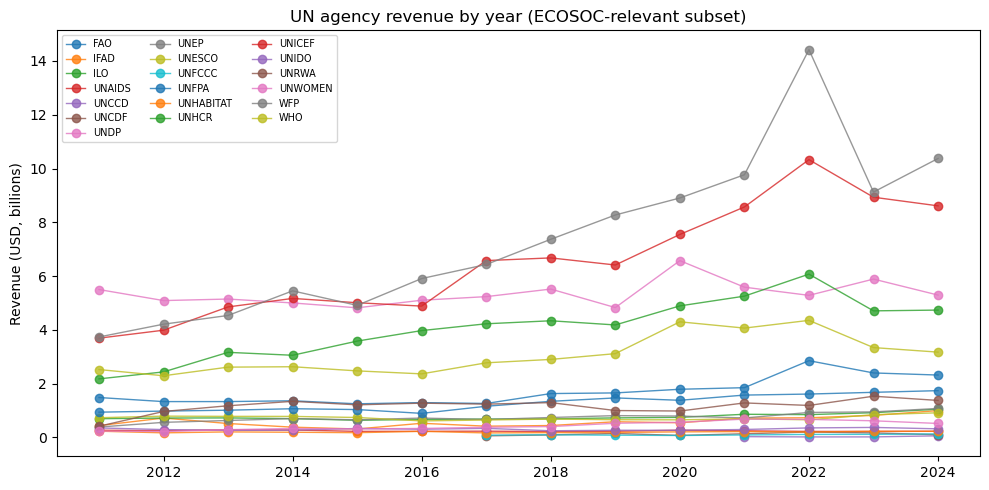

saved /Users/latahviawilliams/Downloads/Big_Data_export/final_project/ecosoc/output/figures/un_revenue_lines.png


In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))
for a, g in panel_e.groupby("agency"):
    ax.plot(g.year, g.revenue_usd / 1e9, marker="o", label=a, alpha=0.8, linewidth=1)
ax.set_ylabel("Revenue (USD, billions)")
ax.set_title("UN agency revenue by year (ECOSOC-relevant subset)")
ax.legend(ncol=3, fontsize=7, loc="upper left")
plt.tight_layout()
fig_path = ROOT / "output" / "figures" / "un_revenue_lines.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150)
plt.show()
print("saved", fig_path)

In [9]:
import altair as alt
import pandas as pd
from pathlib import Path

ROOT = Path.cwd().parent
panel_e = pd.read_parquet(ROOT / "data" / "interim" / "un_panel.parquet")

plot_df = panel_e.assign(revenue_b=panel_e.revenue_usd / 1e9)

chart = (
    alt.Chart(plot_df)
    .mark_line(point=True)
    .encode(
        x=alt.X("year:O", title="Year"),
        y=alt.Y("revenue_b:Q", title="Revenue (USD, billions)"),
        color=alt.Color("agency:N", title="Agency",
                        scale=alt.Scale(scheme="tableau20")),
        tooltip=["agency:N", "year:O",
                 alt.Tooltip("revenue_b:Q", title="Revenue ($B)", format=".2f"),
                 "n_subagencies:Q"],
    )
    .properties(
        width=720,
        height=380,
        title="UN agency revenue by year (ECOSOC-relevant subset)",
    )
    .interactive()
)

hover = alt.selection_point(on="mouseover", fields=["agency"], nearest=True)
chart = chart.encode(opacity=alt.condition(hover, alt.value(1.0), alt.value(0.2))).add_params(hover)

chart.save(str(ROOT / "output" / "figures" / "un_revenue_lines.html"))
chart

/opt/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)
/opt/anaconda3/lib/python3.12/site-packages/altair/utils/core.py:395: FutureWarning: the convert_dtype parameter is deprecated and will be removed in a future version.  Do ``ser.astype(object).apply()`` instead if you want ``convert_dtype=False``.
  col = df[col_name].apply(to_list_if_array, convert_dtype=False)


alt.Chart(...)